# AI Tool Papers Trend and L2 Distribution Analysis

This notebook analyzes the prevalence and characteristics of AI tool–related research papers over time using two datasets:

1. **Generalized Papers Dataset** – a broad sample of research papers across many researchers.
2. **Fellow Papers Dataset** – papers authored by fellows.

The analysis focuses on understanding trends in **AI tool usage** and examining the **distribution of normalized L2 distances** for papers identified as AI-tool related.

## Goal of the Analysis

The goal of this notebook is to better understand:

- How the prevalence of AI tool papers has changed over time.
- Whether the distribution of semantic similarity (measured by normalized L2 distance) shifts for AI-related papers across years.
- Differences between the broader research population and fellows.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
general_path = "/share/yin/kk929_codes/schmidt_vibe/data/intermediates/dimension_sample_papers_ready.parquet"
fellow_path = "/share/yin/kk929_codes/schmidt_vibe/data/intermediates/fellow_papers_ready.parquet"

# Load
general_df = pd.read_parquet(general_path)
fellow_df = pd.read_parquet(fellow_path)

print(general_df.shape)
print(fellow_df.shape)

general_df.head()

(210000, 15)
(7272, 22)


,id,fields,subfields,doi,publication_year,publication_date,l2_raw,l2_normalized,cosine_sim,l2_umap,is_aitool,num_refs,num_refs_aitool,is_ai_james,AIProb
0,pub.1151415559,"[Agricultural, Veterinary and Food Sciences]",[Veterinary Sciences],10.1016/j.rvsc.2022.09.026,2022,2022-09-28,10.475546,0.501541,0.874229,5.788938,0,62,0,NaN,NaN
1,pub.1186428021,None,None,10.56712/latam.v5i5.2665,2024,2024-09-19,8.062587,0.388748,0.924437,9.353022,0,16,1,NaN,NaN
2,pub.1078553491,[Biomedical and Clinical Sciences],"[Cardiovascular Medicine and Haematology, Clin...",None,2012,2012-04-01,10.891627,0.518305,0.865680,8.104331,0,0,0,NaN,NaN
3,pub.1185283823,[Engineering],[Electrical Engineering],10.1364/ol.551436,2025,2025-02-26,11.784606,0.556582,0.845108,4.934591,0,11,0,0.0,0.000022
4,pub.1092118402,None,None,10.1007/978-90-368-1696-0_122,2017,2017-01-01,8.195462,0.393793,0.922463,3.995846,0,8,0,NaN,NaN


### Filter years and AI tool papers
- is_aitool = 1
- years from 2012 to now

In [3]:
start_year = 2012

general_ai = general_df[
    (general_df["is_aitool"] == 1) &
    (general_df["publication_year"] >= start_year)
]

fellow_ai = fellow_df[
    (fellow_df["is_aitool"] == 1) &
    (fellow_df["publication_year"] >= start_year)
]

### Trend of AI-tool papers over time

x = year
y = average AI tool (0 to 1) -- fraction of AI-tool papers per year

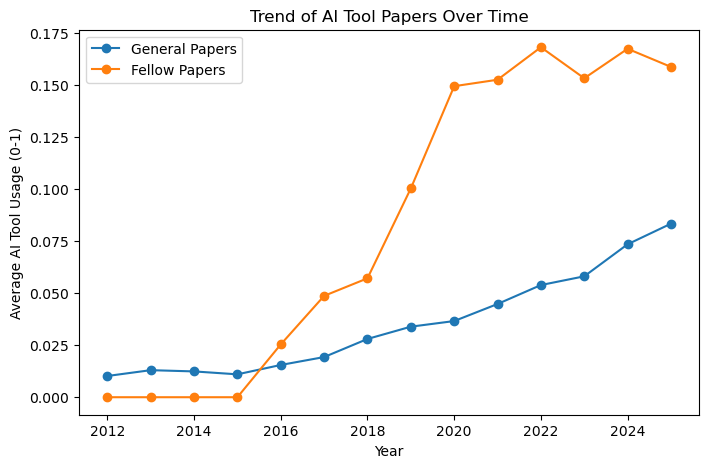

In [6]:
general_trend = (
    general_df[general_df["publication_year"] >= start_year]
    .groupby("publication_year")["is_aitool"]
    .mean()
)

fellow_trend = (
    fellow_df[fellow_df["publication_year"] >= start_year]
    .groupby("publication_year")["is_aitool"]
    .mean()
)
# Plotting
plt.figure(figsize=(8,5))

plt.plot(general_trend.index, general_trend.values, marker='o', label="General Papers")
plt.plot(fellow_trend.index, fellow_trend.values, marker='o', label="Fellow Papers")

plt.xlabel("Year")
plt.ylabel("Average AI Tool Usage (0-1)")
plt.title("Trend of AI Tool Papers Over Time")
plt.legend()
plt.show()

#### Observations: 
- AI tool–related work is growing across all researchers
- Fellows appear to adopt AI tools earlier and at higher rates

#### What the plot shows?
- General papers: steady increase from ~1% in 2012 to ~8% in 2025
- Fellow papers: much sharper increase, reaching ~15–17%

### Distribution of L2 for AI-tools paper

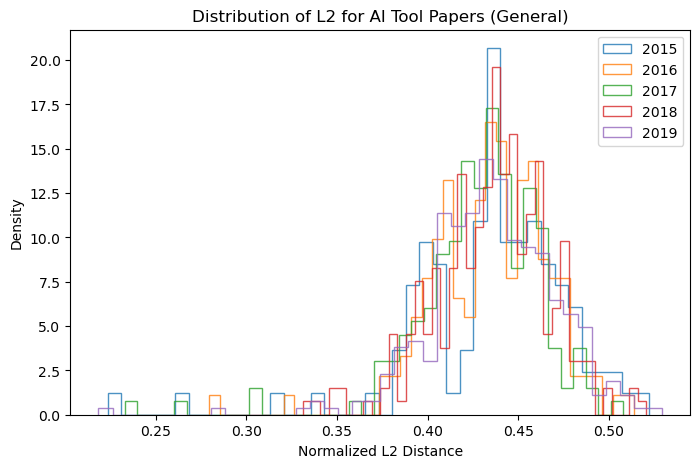

In [ ]:
years = range(2015, 2020)

plt.figure(figsize=(8,5))

for year in years:
    
    x = general_ai[general_ai["publication_year"] == year]["l2_normalized"]
    
    if len(x) > 0:
        plt.hist(
            x,
            bins=40, # np.arange(0, 0.6, 0.1)
            density=True,
            histtype="step",
            alpha=0.8,
            label=str(year)
        )

plt.xlabel("Normalized L2 Distance")
plt.ylabel("Density")
plt.title("Distribution of L2 for AI Tool Papers (General)")
plt.legend()
plt.show()

#### Observations 

- Most values fall between 0.40 – 0.47
- The distributions across years are fairly similar
- Slight spread between 0.35 – 0.50

#### Interpretation
- AI tool papers tend to occupy a similar semantic space
- The topic similarity structure of AI-related papers is relatively stable


Some small shifts toward lower L2 values in later years could indicate:
- AI tools becoming more standardized in research workflows

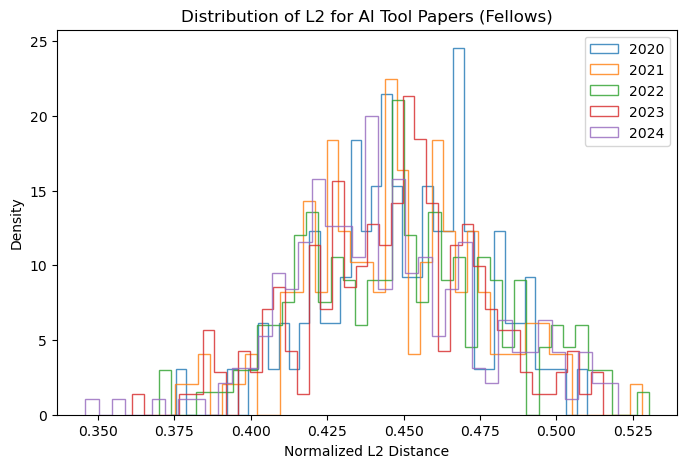

In [ ]:
years = range(2020, 2025)

plt.figure(figsize=(8,5))

for year in years:
    
    x = fellow_ai[fellow_ai["publication_year"] == year]["l2_normalized"]
    
    if len(x) > 0:
        plt.hist(
            x,
            bins=40, # dont do bins 
            density=True,
            histtype="step",
            alpha=0.8,
            label=str(year)
        )

plt.xlabel("Normalized L2 Distance")
plt.ylabel("Density")
plt.title("Distribution of L2 for AI Tool Papers (Fellows)")
plt.legend()
plt.show()

Very spiky density values
- Some peaks go up to 200+

Narrow distributions around ~0.43–0.46

This is not a real phenomenon of the data — it's mostly a sample size effect.

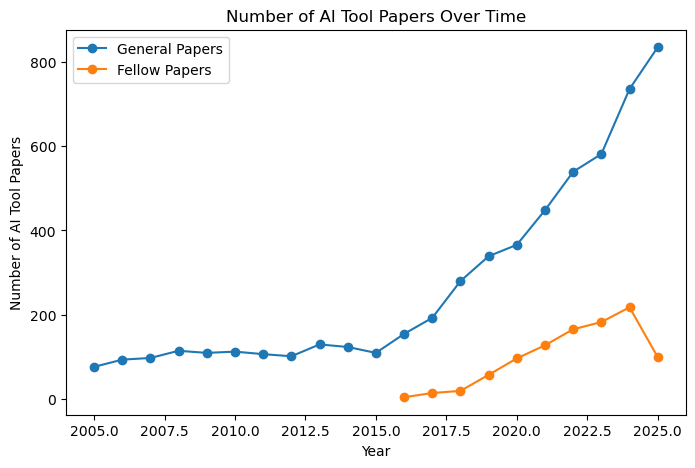

In [20]:
# Number of AI Tool Papers per Year
general_counts = general_df[general_df["is_aitool"] == 1].groupby("publication_year").size()
fellow_counts = fellow_df[fellow_df["is_aitool"] == 1].groupby("publication_year").size()

# Plotting
plt.figure(figsize=(8,5))
plt.plot(general_counts.index, general_counts.values, marker='o', label="General Papers")
plt.plot(fellow_counts.index, fellow_counts.values, marker='o', label="Fellow Papers")
plt.xlabel("Year")
plt.ylabel("Number of AI Tool Papers")
plt.title("Number of AI Tool Papers Over Time")
plt.legend()
plt.show()

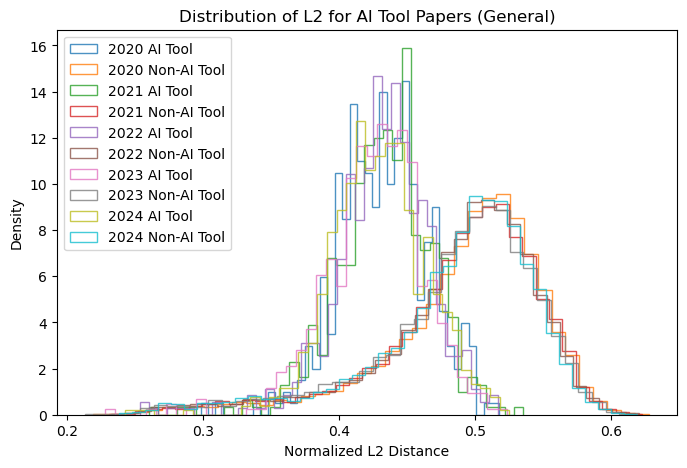

In [21]:
# Compare L2 Distribution: AI vs Non-AI Papers

plt.figure(figsize=(8,5))
for year in years:
    
    x_ai = general_df[
        (general_df["publication_year"] == year) &
        (general_df["is_aitool"] == 1)
    ]["l2_normalized"]
    
    x_non_ai = general_df[
        (general_df["publication_year"] == year) &
        (general_df["is_aitool"] == 0)
    ]["l2_normalized"]
    
    if len(x_ai) > 0:
        plt.hist(
            x_ai,
            bins=40,
            density=True,
            histtype="step",
            alpha=0.8,
            label=f"{year} AI Tool"
        )
    
    if len(x_non_ai) > 0:
        plt.hist(
            x_non_ai,
            bins=40,
            density=True,
            histtype="step",
            alpha=0.8,
            label=f"{year} Non-AI Tool"
        )
plt.xlabel("Normalized L2 Distance")
plt.ylabel("Density")
plt.title("Distribution of L2 for AI Tool Papers (General)")
plt.legend()
plt.show()

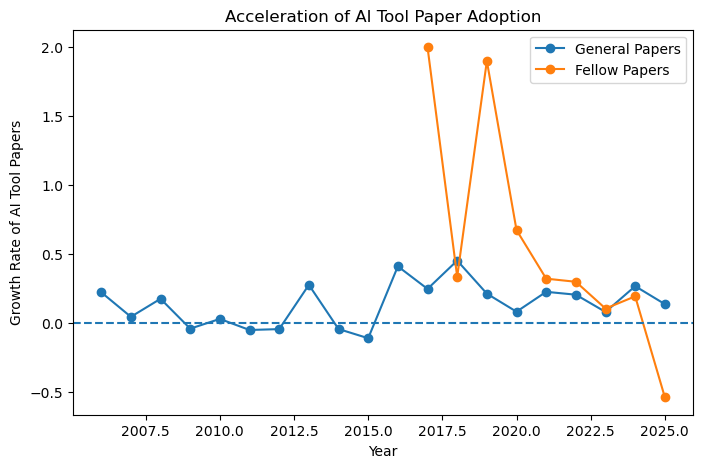

In [24]:
# Growth rate of AI Tool Papers
general_ai_counts = (
    general_df[general_df["is_aitool"] == 1]
    .groupby("publication_year")
    .size()
)

fellow_ai_counts = (
    fellow_df[fellow_df["is_aitool"] == 1]
    .groupby("publication_year")
    .size()
)

general_growth = general_ai_counts.pct_change()
fellow_growth = fellow_ai_counts.pct_change()

# Plotting
plt.figure(figsize=(8,5))

plt.plot(general_growth.index, general_growth.values, marker="o", label="General Papers")
plt.plot(fellow_growth.index, fellow_growth.values, marker="o", label="Fellow Papers")

plt.axhline(0, linestyle="--")

plt.xlabel("Year")
plt.ylabel("Growth Rate of AI Tool Papers")
plt.title("Acceleration of AI Tool Paper Adoption")
plt.legend()

plt.show()

---
# New Updates

## L2 Similarity Analysis of AI Tool Usage

This part examines how the distribution of **L2 similarity scores** differs across different types of papers and time periods.

The analysis focuses on three groups of papers:

1. **AI Tool Producers** – papers that develop or introduce AI tools (`is_AITool = 1`)
2. **AI Tool Consumers** – papers that do not produce AI tools but reference or use them (`is_AITool = 0` and `num_ai_toolRef >= 1`)
3. **Neither Producers nor Consumers** – papers that neither produce nor reference AI tools (`is_AITool = 0` and `num_ai_toolRef = 0`)

For each group, we analyze the **distribution of normalized L2 distance** across three time periods:

- 2015–2019
- 2020–2022
- 2023–2025

The goal is to observe whether the similarity distribution changes over time and how it differs across these categories of papers.


In [4]:
bins = np.linspace(0.2, 0.6, 40)

def plot_periods(df, title):

    periods = {
        "2015-2019": (2015, 2019),
        "2020-2022": (2020, 2022),
        "2023-2025": (2023, 2025)
    }

    plt.figure(figsize=(8,5))

    for label, (start, end) in periods.items():

        x = df[(df["publication_year"] >= start) &
               (df["publication_year"] <= end)]["l2_normalized"]

        if len(x) > 0:
            plt.hist(
                x,
                bins=bins,
                density=True,
                histtype="step",
                linewidth=2,
                label=label
            )

    plt.xlabel("Normalized L2 Distance")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()


## Figure 1: AI Tool Producers

This figure shows the distribution of L2 similarity scores for papers that **produce AI tools** (`is_AITool = 1`).

Three curves represent the following time periods:

- 2015–2019
- 2020–2022
- 2023–2025

This allows us to observe whether the similarity scores for AI tool papers shift over time.


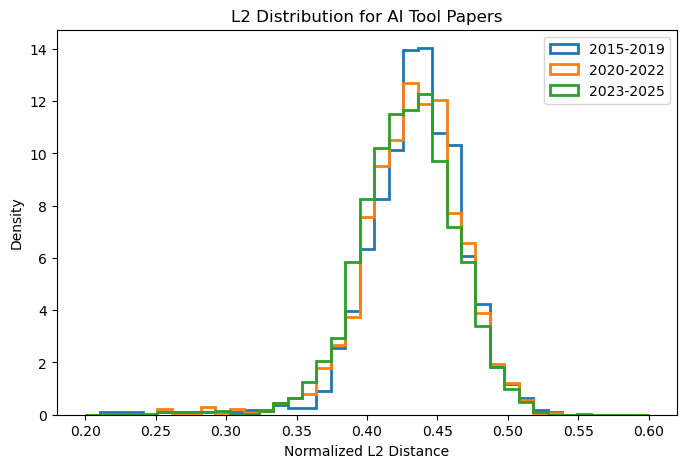

In [13]:
producers = general_df[general_df["is_aitool"] == 1]

plot_periods(
    producers,
    "L2 Distribution for AI Tool Papers"
)

## Figure 2: AI Tool Consumers

This figure shows papers that **do not produce AI tools but reference**.

Condition used:

is_AITool = 0  
num_ai_toolRef ≥ 1

These papers represent researchers who **use or cite AI tools developed by others**.


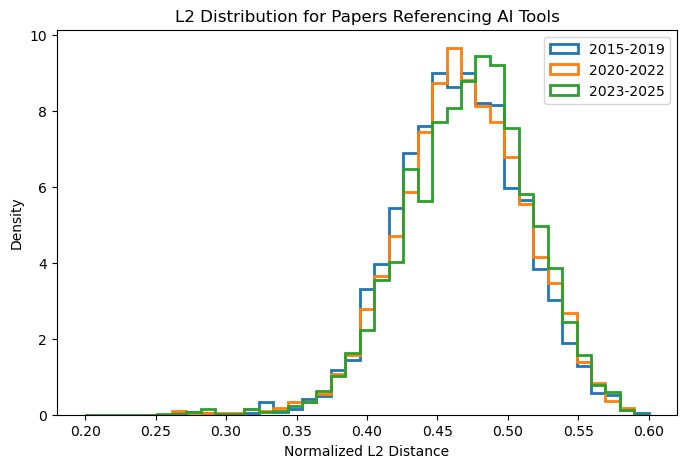

In [14]:
consumers = general_df[
    (general_df["is_aitool"] == 0) &
    (general_df["num_refs_aitool"] >= 1)
]

plot_periods(
    consumers,
    "L2 Distribution for Papers Referencing AI Tools"
)

## Figure 3: Neither Producers nor Consumers

This figure shows papers that **neither produce AI tools nor reference them**.

Condition used:

is_AITool = 0  
num_ai_toolRef = 0

These papers represent research that is **unrelated to AI tool development or usage**.


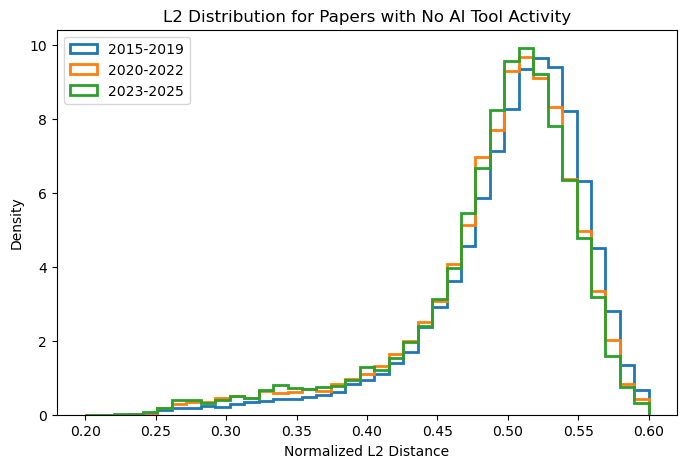

In [11]:
neither = general_df[
    (general_df["is_aitool"] == 0) &
    (general_df["num_refs_aitool"] == 0)
]
plot_periods(
    neither,
    "L2 Distribution for Papers with No AI Tool Activity"
)

In [15]:
# Create summary table
summary = pd.DataFrame({
    "Group": [
        "AI Tool Producers",
        "AI Tool Consumers",
        "No AI Tool Activity"
    ],
    "Mean L2": [
        producers["l2_normalized"].mean(),
        consumers["l2_normalized"].mean(),
        neither["l2_normalized"].mean()
    ],
    "Std L2": [
        producers["l2_normalized"].std(),
        consumers["l2_normalized"].std(),
        neither["l2_normalized"].std()
    ],
    "Count": [
        len(producers),
        len(consumers),
        len(neither)
    ]
})

summary

,Group,Mean L2,Std L2,Count
0,AI Tool Producers,0.431459,0.034326,5650
1,AI Tool Consumers,0.467894,0.043784,10528
2,No AI Tool Activity,0.505061,0.055993,193822


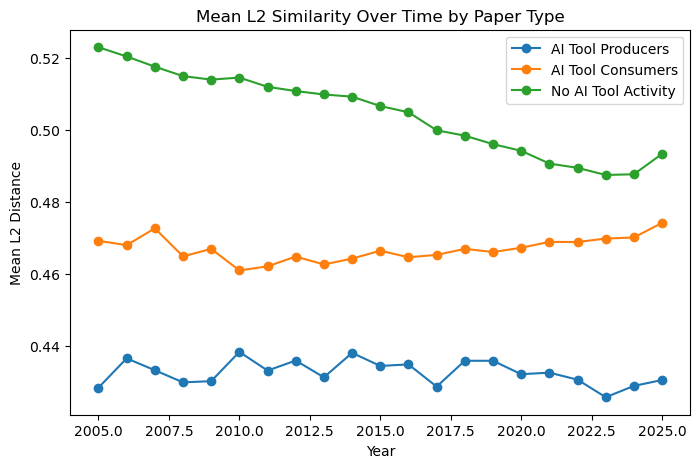

In [16]:
# Compute mean L2 per year for each group
prod_year = producers.groupby("publication_year")["l2_normalized"].mean()
cons_year = consumers.groupby("publication_year")["l2_normalized"].mean()
neither_year = neither.groupby("publication_year")["l2_normalized"].mean()

plt.figure(figsize=(8,5))

plt.plot(prod_year.index, prod_year.values, marker="o", label="AI Tool Producers")
plt.plot(cons_year.index, cons_year.values, marker="o", label="AI Tool Consumers")
plt.plot(neither_year.index, neither_year.values, marker="o", label="No AI Tool Activity")

plt.xlabel("Year")
plt.ylabel("Mean L2 Distance")
plt.title("Mean L2 Similarity Over Time by Paper Type")

plt.legend()
plt.show()

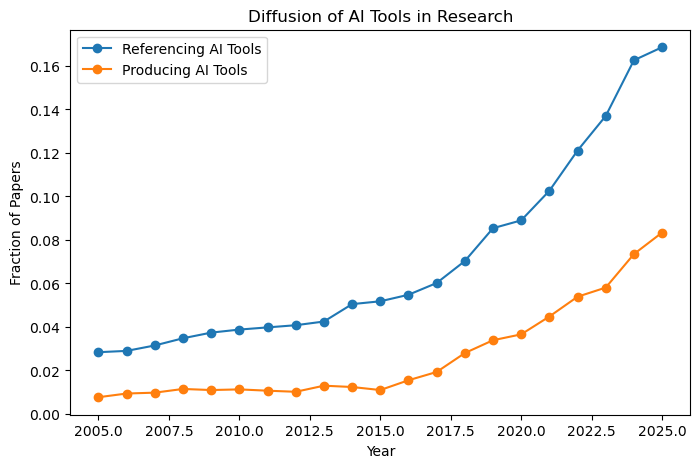

In [19]:
# Papers referencing AI tools
ai_ref_rate = (
    (general_df["num_refs_aitool"] >= 1)
    .groupby(general_df["publication_year"])
    .mean()
)

# Papers producing AI tools
ai_prod_rate = (
    (general_df["is_aitool"] == 1)
    .groupby(general_df["publication_year"])
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(ai_ref_rate.index, ai_ref_rate.values, marker="o", label="Referencing AI Tools")
plt.plot(ai_prod_rate.index, ai_prod_rate.values, marker="o", label="Producing AI Tools")

plt.xlabel("Year")
plt.ylabel("Fraction of Papers")
plt.title("Diffusion of AI Tools in Research")

plt.legend()
plt.show()


In [22]:
ai_producers_count = (
    (general_df["is_aitool"] == 1)
    .groupby(general_df["publication_year"])
    .sum()
)

sum(ai_producers_count)

5650

In [24]:
ai_consumers_count = (
    (general_df["num_refs_aitool"] >= 1)
    .groupby(general_df["publication_year"])
    .sum()
)

sum(ai_consumers_count)


14769

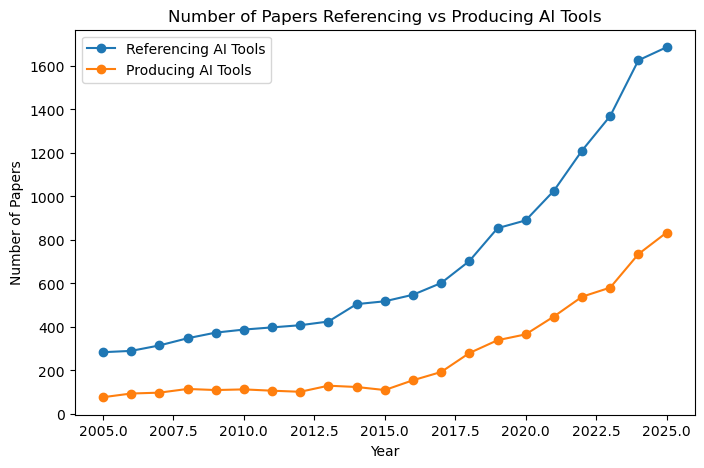

In [25]:
import matplotlib.pyplot as plt

years = ai_producers_count.index

plt.figure(figsize=(8,5))

plt.plot(years, ai_consumers_count, marker="o", label="Referencing AI Tools")
plt.plot(years, ai_producers_count, marker="o", label="Producing AI Tools")

plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.title("Number of Papers Referencing vs Producing AI Tools")

plt.legend()
plt.show()


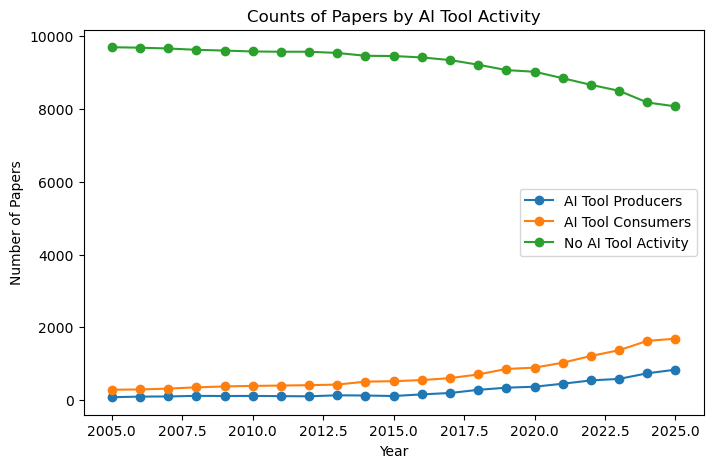

In [27]:
neither_count = (
    ((general_df["is_aitool"] == 0) & (general_df["num_refs_aitool"] == 0))
    .groupby(general_df["publication_year"])
    .sum()
)

plt.figure(figsize=(8,5))

plt.plot(years, ai_producers_count, marker="o", label="AI Tool Producers")
plt.plot(years, ai_consumers_count, marker="o", label="AI Tool Consumers")
plt.plot(years, neither_count, marker="o", label="No AI Tool Activity")

plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.title("Counts of Papers by AI Tool Activity")

plt.legend()
plt.show()
